### Instalación de dependencias del proyecto

In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

random.seed(99)

import yaml

import sys
from PIL import Image, ImageFile

# Configuración del proyecto
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()

# Agregar el directorio raíz del proyecto al sys.path para importar módulos personalizados
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
# Cargar la configuración del proyecto desde el archivo YAML
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [ ]:
# Descargar el dataset desde Kaggle utilizando la API de Kaggle
!curl -L -o ../data/raw/bone-break-classification-image-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/pkdarabi/bone-break-classification-image-dataset

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0
100 28.44M 100 28.44M   0      0 13.64M      0   00:02   00:02          2.57M


In [ ]:
# Definir las rutas para el archivo ZIP y la carpeta de extracción
zip_path = PROJECT_ROOT / config["path"]["raw_data_dir"] / "bone-break-classification-image-dataset.zip"
extract_path = PROJECT_ROOT / config["path"]["raw_data_dir"] / "dataset_fracturas"

if extract_path.exists() and any(extract_path.iterdir()):
    # Si la carpeta de extracción ya existe y no está vacía,
    # asumimos que el dataset ya ha sido extraído
    print(f"El dataset ya existe")
else:
    if not zip_path.exists():
        raise FileNotFoundError(f"El archivo ZIP no se encontró en: {zip_path}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    # Eliminar el archivo ZIP
    os.remove(zip_path)

Ver estructura de carpetas

In [43]:
def mostrar_estructura(ruta: Path, nivel_max=4):
    for root, dirs, files in os.walk(ruta):
        nivel = root.replace(str(ruta), "").count(os.sep)

        if nivel > nivel_max:
            continue

        indentacion = "    " * nivel
        nombre_carpeta = os.path.basename(root)

        imagenes = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
        ]

        print(f"{indentacion}{nombre_carpeta}/  ({len(imagenes)} imágenes)")

mostrar_estructura(extract_path, nivel_max=5)

dataset_fracturas/  (0 imágenes)
    Bone Break Classification/  (0 imágenes)
        Bone Break Classification/  (0 imágenes)
            Avulsion fracture/  (0 imágenes)
                Test/  (14 imágenes)
                Train/  (109 imágenes)
            Comminuted fracture/  (0 imágenes)
                Test/  (14 imágenes)
                Train/  (134 imágenes)
            Fracture Dislocation/  (0 imágenes)
                Test/  (19 imágenes)
                Train/  (137 imágenes)
            Greenstick fracture/  (0 imágenes)
                Test/  (16 imágenes)
                Train/  (106 imágenes)
            Hairline Fracture/  (0 imágenes)
                Test/  (10 imágenes)
                Train/  (101 imágenes)
            Impacted fracture/  (0 imágenes)
                Test/  (9 imágenes)
                Train/  (75 imágenes)
            Longitudinal fracture/  (0 imágenes)
                Test/  (12 imágenes)
                Train/  (68 imágenes)
            Obliqu

Crear DataFrame con información de cada imagen

In [77]:
extensiones_img = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

rutas_imagenes = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(extensiones_img):
            rutas_imagenes.append(Path(root) / file)

print("Total de imágenes encontradas:", len(rutas_imagenes))

Total de imágenes encontradas: 1129


In [78]:
datos = []

for ruta in rutas_imagenes:
    partes = ruta.parts

    categoria = ruta.parent.parent.name
    split = ruta.parent.name

    try:
        img = Image.open(ruta)

        ancho, alto = img.size
        modo = img.mode

        img_array = np.array(img)

        # Convertimos a escala de grises solo para estadísticas
        img_gray = img.convert("L")
        gray_array = np.array(img_gray)

        # Verificar si visualmente es gris aunque esté guardada como RGB
        if img_array.ndim == 3 and img_array.shape[2] >= 3:
            es_gris_visual = np.allclose(img_array[:, :, 0], img_array[:, :, 1]) and \
                             np.allclose(img_array[:, :, 1], img_array[:, :, 2])
        else:
            es_gris_visual = True

        ruta_relativa = ruta.relative_to(PROJECT_ROOT)

        datos.append({
            "ruta": str(ruta_relativa),
            "archivo": ruta.name,
            "categoria": categoria,
            "split": split,
            "ancho": ancho,
            "alto": alto,
            "pixeles_totales": ancho * alto,
            "relacion_aspecto": ancho / alto,
            "modo": modo,
            "es_gris_visual": es_gris_visual,
            "intensidad_min": gray_array.min(),
            "intensidad_max": gray_array.max(),
            "intensidad_media": gray_array.mean(),
            "intensidad_std": gray_array.std()
        })

    except Exception as e:
        print("Error leyendo:", ruta)
        print(e)

df = pd.DataFrame(datos)

df.head()

,ruta,archivo,categoria,split,ancho,alto,pixeles_totales,relacion_aspecto,modo,es_gris_visual,intensidad_min,intensidad_max,intensidad_media,intensidad_std
0,data/raw/dataset_fracturas/Bone Break Classifi...,000002_png.rf.c3e00ebc2db78bc94e644c3f6605dad0...,Avulsion fracture,Test,640,640,409600,1.000000,RGB,True,38,228,149.882522,30.616164
1,data/raw/dataset_fracturas/Bone Break Classifi...,05cc2e0302957e0ad27edb6b9ffbc2_jumbo_jpg.rf.c1...,Avulsion fracture,Test,640,640,409600,1.000000,RGB,True,0,250,46.023774,57.114264
2,data/raw/dataset_fracturas/Bone Break Classifi...,1-s2-0-S0899707114002836-gr2_jpg.rf.bb8ed4dee8...,Avulsion fracture,Test,351,526,184626,0.667300,RGB,True,0,255,75.579008,48.063471
3,data/raw/dataset_fracturas/Bone Break Classifi...,13256_2019_2325_Fig1_HTML_png.rf.09368fddb2da3...,Avulsion fracture,Test,286,603,172458,0.474295,RGB,True,0,255,134.934981,54.742886
4,data/raw/dataset_fracturas/Bone Break Classifi...,13256_2019_2325_Fig1_HTML_png.rf.09368fddb2da3...,Avulsion fracture,Test,219,378,82782,0.579365,RGB,True,0,255,119.130125,55.926034


In [79]:
df.shape

(1129, 14)

In [117]:
categorias = df["categoria"].unique().tolist()
categorias

['Avulsion fracture',
 'Comminuted fracture',
 'Fracture Dislocation',
 'Greenstick fracture',
 'Hairline Fracture',
 'Impacted fracture',
 'Longitudinal fracture',
 'Oblique fracture',
 'Pathological fracture',
 'Spiral Fracture']

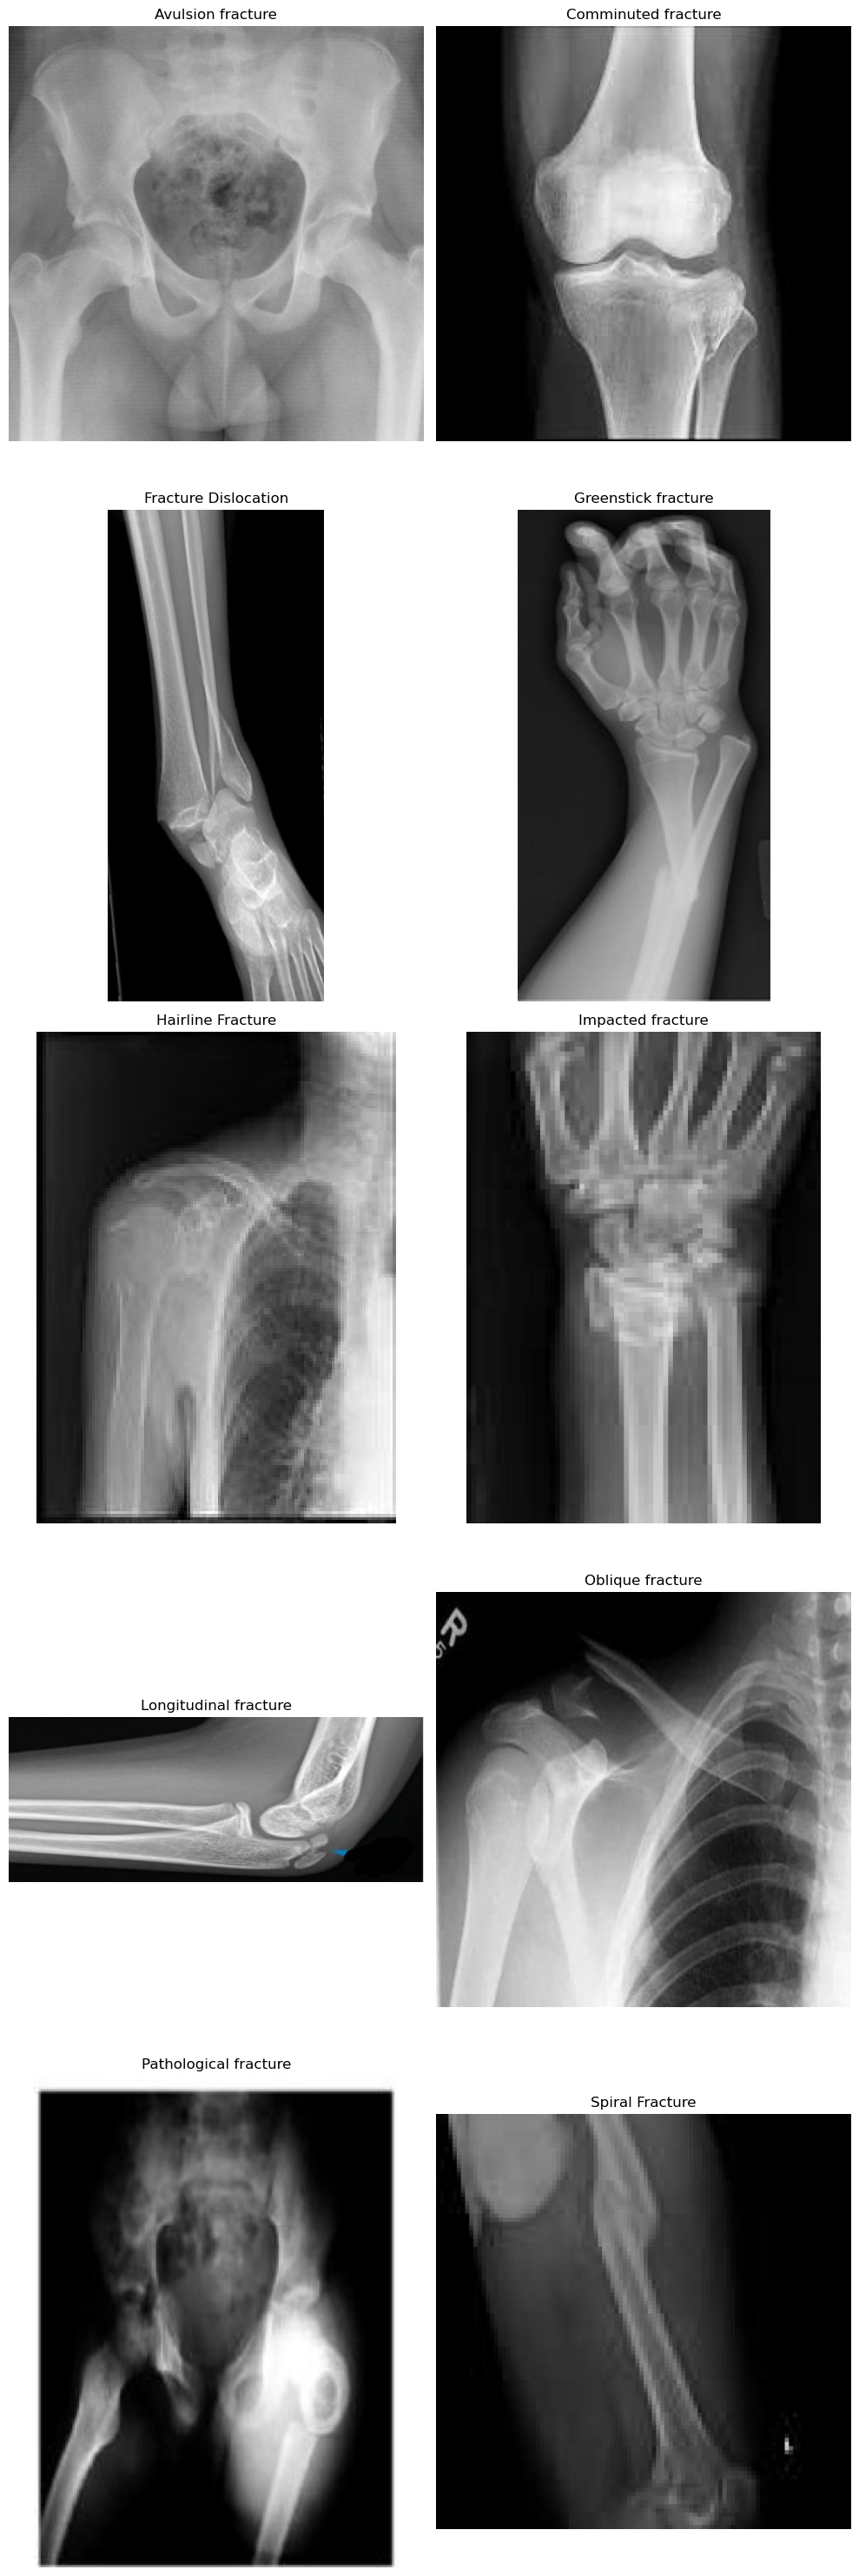

In [134]:
n_cols = 2
n_rows = len(categorias) // n_cols + (len(categorias) % n_cols > 0)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 6*n_rows))
ax = ax.flatten()

for i, categoria in enumerate(categorias):
    cantidad_categoria = df[df["categoria"] == categoria].shape[0]

    random_idx = random.randint(0, cantidad_categoria - 1)

    ruta_imagen_categoria = PROJECT_ROOT / df[df["categoria"] == categoria].iloc[random_idx]["ruta"]

    img = Image.open(ruta_imagen_categoria)

    ax[i].imshow(img)
    ax[i].set_title(categoria)
    ax[i].axis("off")

for j in range(len(categorias), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

**Punto 1: Tamaño de las imágenes**



In [80]:
#Resumen estadístico
df[["ancho", "alto", "pixeles_totales", "relacion_aspecto"]].describe().round(2)

,ancho,alto,pixeles_totales,relacion_aspecto
count,1129.00,1129.00,1129.00,1129.00
mean,430.37,560.48,249573.89,0.83
std,197.34,139.14,136502.61,0.55
min,58.00,77.00,9280.00,0.14
25%,248.00,558.00,130560.00,0.46
50%,443.00,640.00,213368.00,0.84
75%,640.00,640.00,409600.00,1.00
max,640.00,640.00,409600.00,5.82


In [81]:
#Tamaños más frecuentes
tamanios = df.groupby(["ancho", "alto"]).size().reset_index(name="cantidad")
tamanios = tamanios.sort_values("cantidad", ascending=False)

tamanios.head(20)

,ancho,alto,cantidad
641,640,640,380
82,163,640,4
636,640,590,4
334,291,640,4
65,150,640,4
515,515,515,3
292,275,640,3
183,214,640,3
390,320,640,3
381,316,640,3


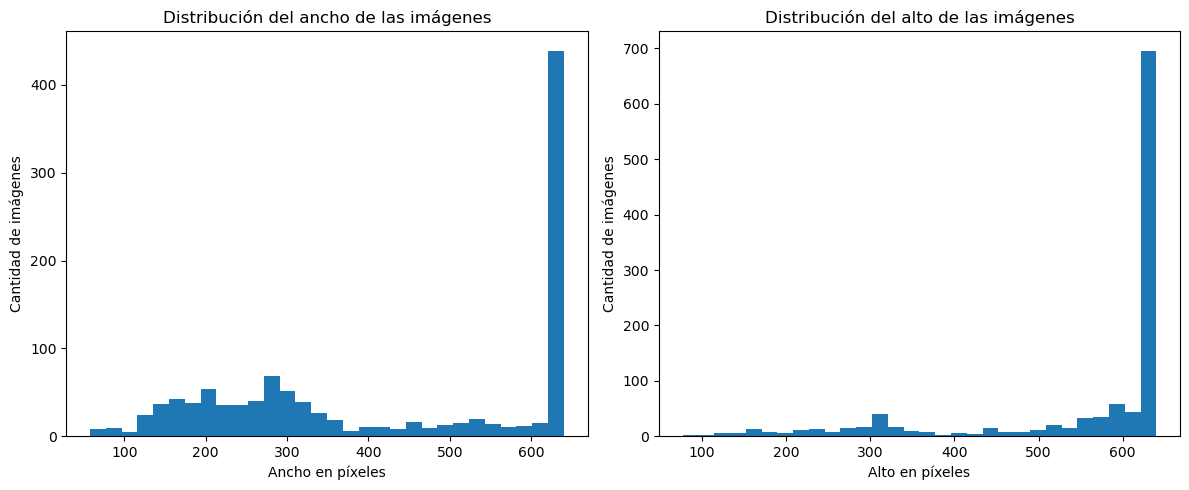

In [82]:
#Gráfico de distribución de ancho y alto
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["ancho"], bins=30)
plt.title("Distribución del ancho de las imágenes")
plt.xlabel("Ancho en píxeles")
plt.ylabel("Cantidad de imágenes")

plt.subplot(1, 2, 2)
plt.hist(df["alto"], bins=30)
plt.title("Distribución del alto de las imágenes")
plt.xlabel("Alto en píxeles")
plt.ylabel("Cantidad de imágenes")

plt.tight_layout()
plt.show()

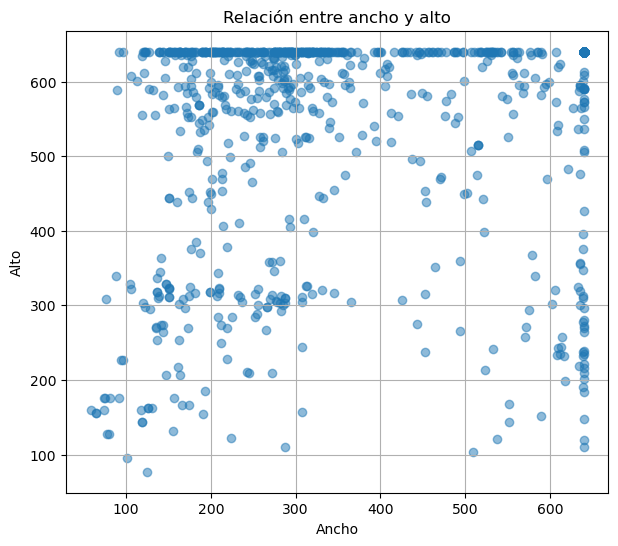

In [83]:
#Relación ancho vs alto
plt.figure(figsize=(7, 6))
plt.scatter(df["ancho"], df["alto"], alpha=0.5)
plt.title("Relación entre ancho y alto")
plt.xlabel("Ancho")
plt.ylabel("Alto")
plt.grid(True)
plt.show()

**Punto 2: Distribución de categorías de las imágenes**

In [84]:
#Conteo por categoría
conteo_categorias = df["categoria"].value_counts().sort_values(ascending=False)

conteo_categorias

categoria
Fracture Dislocation     156
Comminuted fracture      148
Pathological fracture    134
Avulsion fracture        123
Greenstick fracture      122
Hairline Fracture        111
Spiral Fracture           86
Oblique fracture          85
Impacted fracture         84
Longitudinal fracture     80
Name: count, dtype: int64

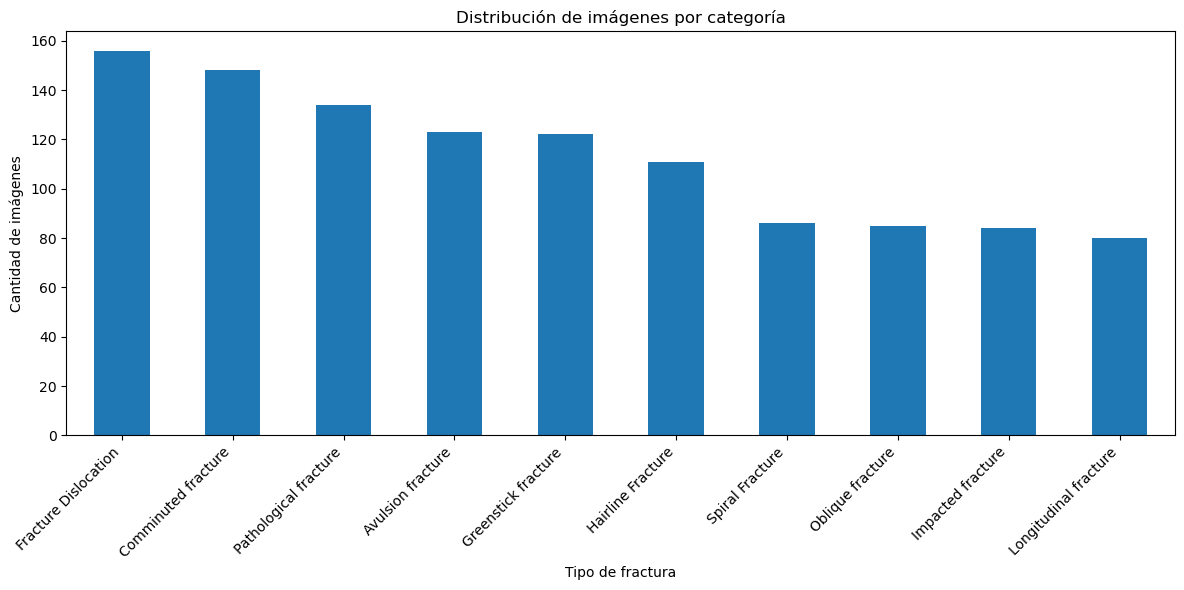

In [85]:
#Gráfico de barras por categoría
plt.figure(figsize=(12, 6))
conteo_categorias.plot(kind="bar")
plt.title("Distribución de imágenes por categoría")
plt.xlabel("Tipo de fractura")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [86]:
#Conteo por categoría y split
tabla_categoria_split = pd.crosstab(df["categoria"], df["split"])

tabla_categoria_split

split,Test,Train
categoria,,
Avulsion fracture,14,109
Comminuted fracture,14,134
Fracture Dislocation,19,137
Greenstick fracture,16,106
Hairline Fracture,10,101
Impacted fracture,9,75
Longitudinal fracture,12,68
Oblique fracture,16,69
Pathological fracture,18,116


In [87]:
import matplotlib.pyplot as plt
import pandas as pd

# Tabla de conteo por categoría y split
tabla_categoria_split = pd.crosstab(df["categoria"], df["split"])

# Asegurar orden de columnas si existen
orden_splits = ["Train", "Test"]
tabla_categoria_split = tabla_categoria_split[[col for col in orden_splits if col in tabla_categoria_split.columns]]

# Convertir cada fila a porcentaje
tabla_porcentaje = tabla_categoria_split.div(tabla_categoria_split.sum(axis=1), axis=0) * 100

tabla_porcentaje

split,Train,Test
categoria,,
Avulsion fracture,88.617886,11.382114
Comminuted fracture,90.540541,9.459459
Fracture Dislocation,87.820513,12.179487
Greenstick fracture,86.885246,13.114754
Hairline Fracture,90.990991,9.009009
Impacted fracture,89.285714,10.714286
Longitudinal fracture,85.000000,15.000000
Oblique fracture,81.176471,18.823529
Pathological fracture,86.567164,13.432836


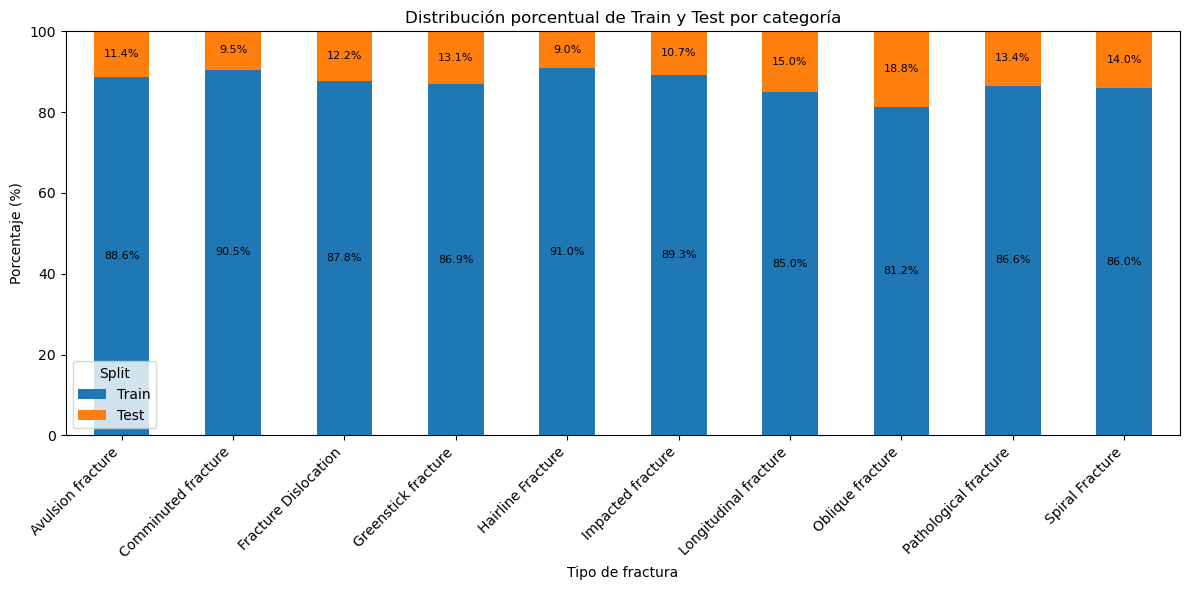

In [88]:
ax = tabla_porcentaje.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribución porcentual de Train y Test por categoría")
plt.xlabel("Tipo de fractura")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.legend(title="Split")

# Agregar etiquetas de porcentaje
for container in ax.containers:
    labels = [
        f"{valor.get_height():.1f}%" if valor.get_height() > 0 else ""
        for valor in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

**Punto 3: Histogramas promedio**

In [89]:
#Carga de imagen
def cargar_gris(ruta):
    img = Image.open(ruta).convert("L")
    return np.array(img)

def calcular_histograma_gray(ruta):
    img_gray = cargar_gris(ruta)

    hist, bins = np.histogram(
        img_gray.ravel(),
        bins=256,
        range=(0, 256),
        density=True
    )

    return hist

In [90]:
#Histograma promedio general del dataset
histogramas = []

for ruta_relativa in df["ruta"]:
    ruta_absoluta = PROJECT_ROOT / ruta_relativa
    hist = calcular_histograma_gray(ruta_absoluta)
    histogramas.append(hist)

histogramas = np.array(histogramas)

hist_promedio_general = histogramas.mean(axis=0)

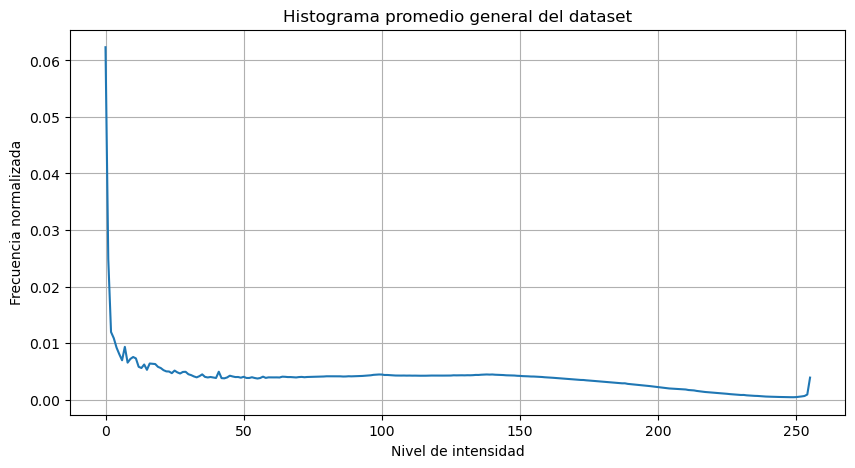

In [91]:
plt.figure(figsize=(10, 5))
plt.plot(hist_promedio_general)
plt.title("Histograma promedio general del dataset")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia normalizada")
plt.grid(True)
plt.show()

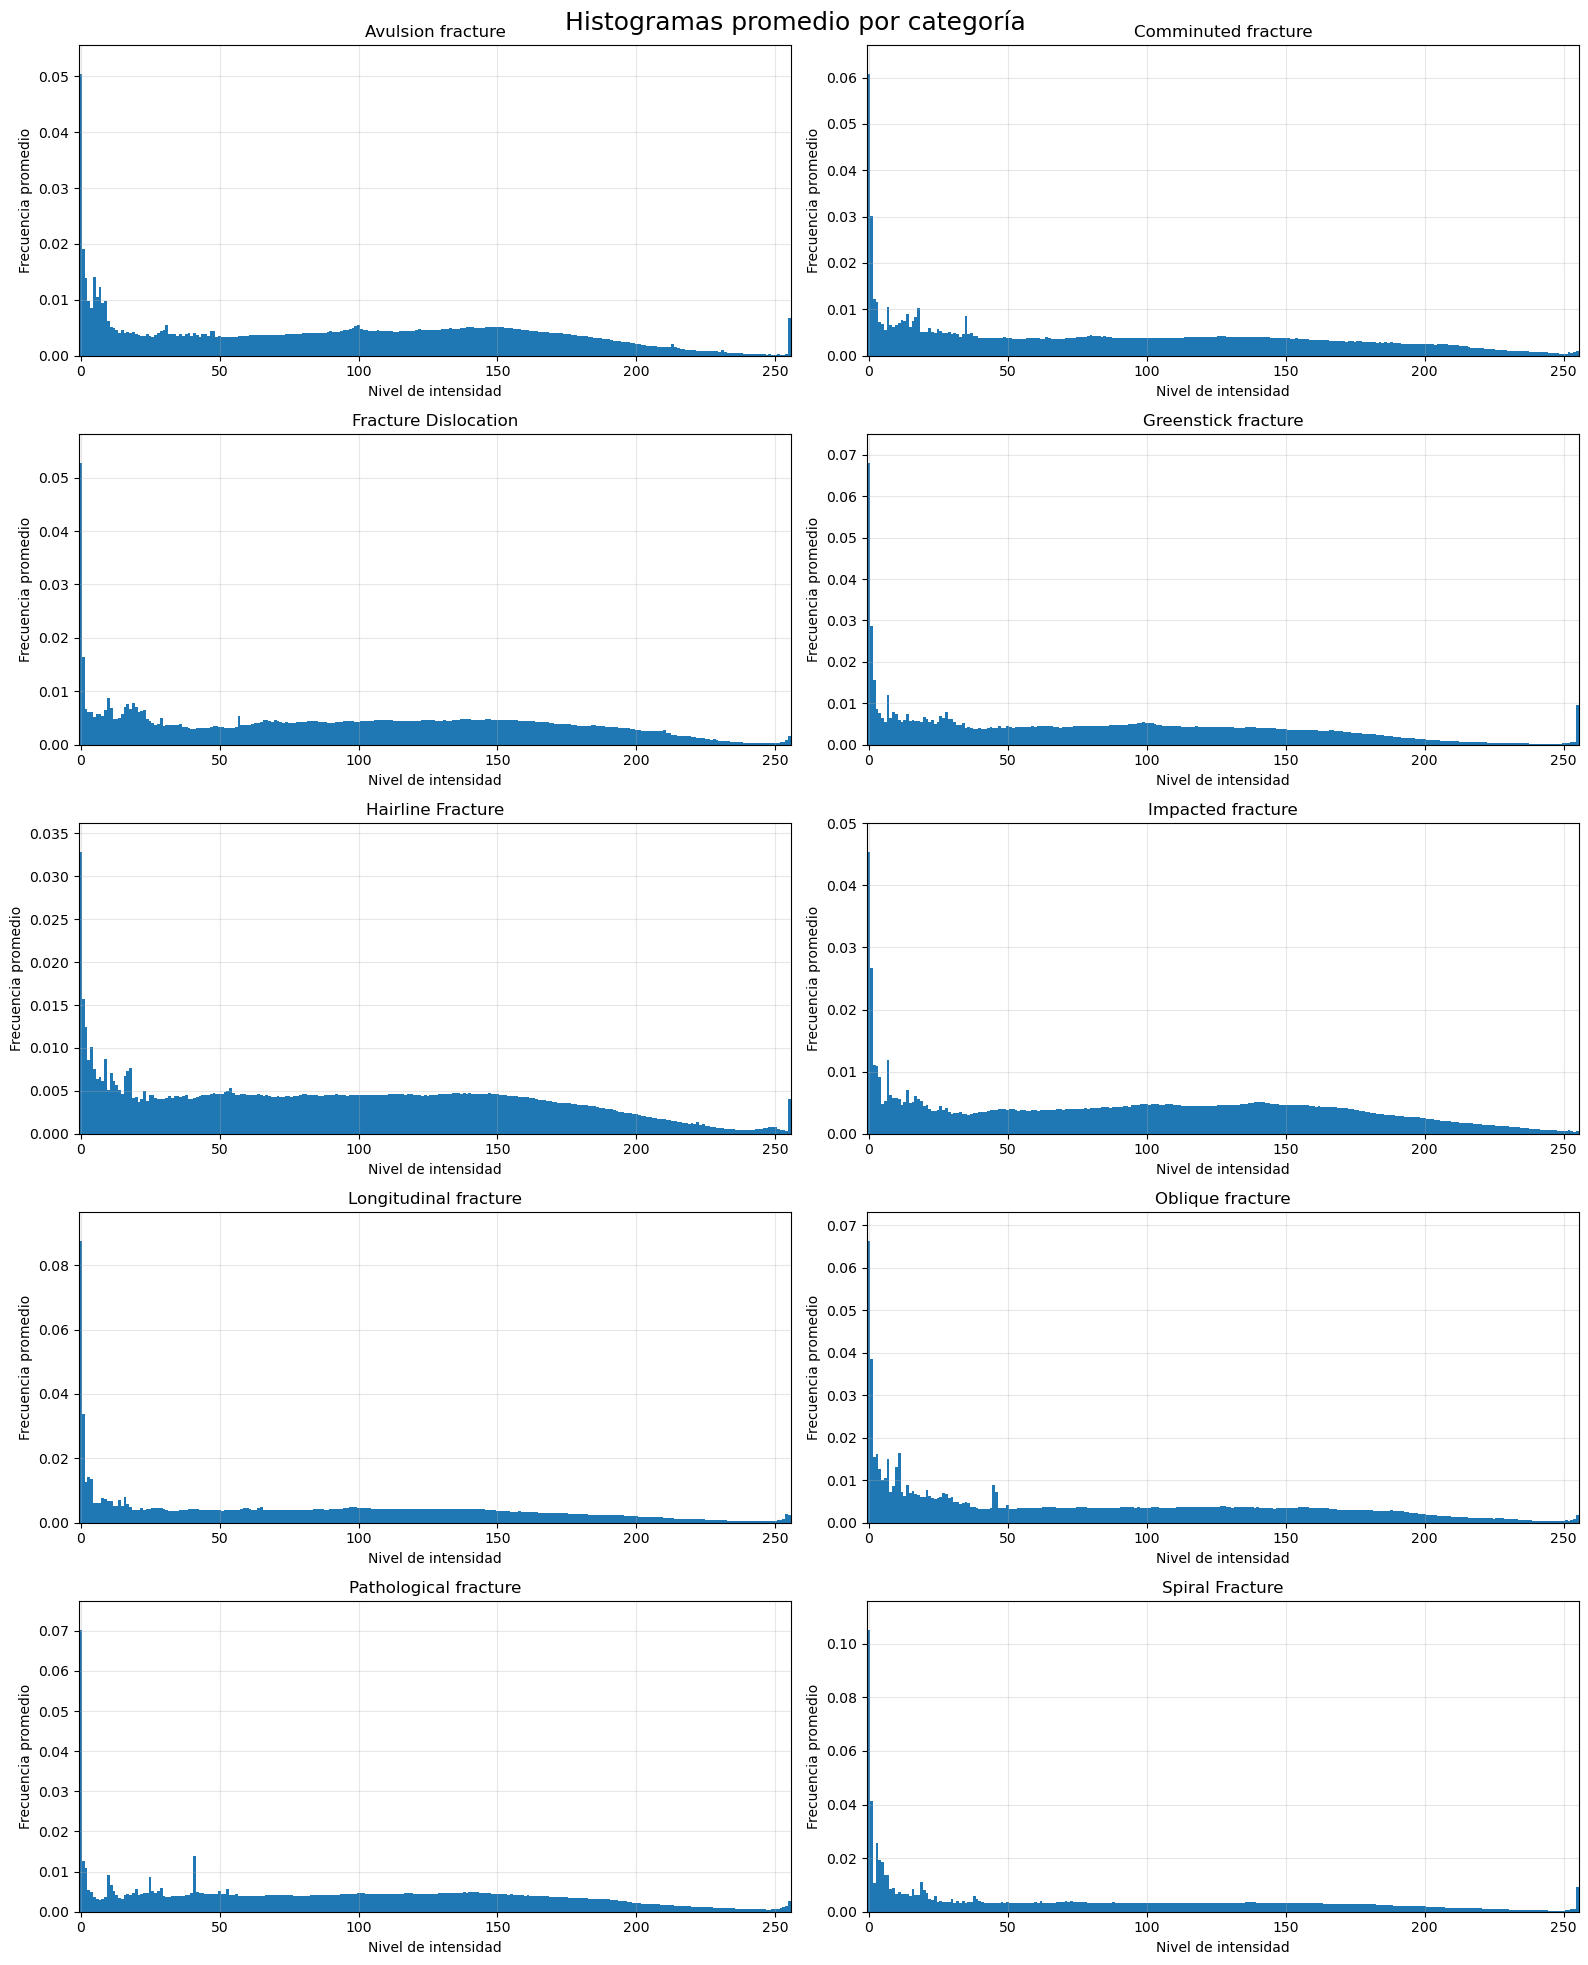

In [94]:
#Histograma promedio por categoría
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

# Función para calcular histograma en escala de grises
def calcular_histograma_gray(ruta):
    img = Image.open(ruta).convert("L")
    img_array = np.array(img)

    hist, _ = np.histogram(
        img_array.ravel(),
        bins=256,
        range=(0, 256),
        density=True
    )

    return hist

# Categorías únicas
categorias = sorted(df["categoria"].unique())

# Configuración de subplots
n_categorias = len(categorias)
columnas = 2
filas = math.ceil(n_categorias / columnas)

fig, axes = plt.subplots(filas, columnas, figsize=(16, filas * 4))

# Aplanamos axes para recorrerlo fácil
axes = axes.flatten()

# Eje X: niveles de intensidad 0-255
niveles_intensidad = np.arange(256)

for i, categoria in enumerate(categorias):
    rutas_categoria = df[df["categoria"] == categoria]["ruta"]

    histogramas_categoria = []

    for ruta_relativa in rutas_categoria:
        ruta_absoluta = PROJECT_ROOT / ruta_relativa
        hist = calcular_histograma_gray(ruta_absoluta)
        histogramas_categoria.append(hist)

    hist_promedio = np.array(histogramas_categoria).mean(axis=0)

    axes[i].bar(niveles_intensidad, hist_promedio, width=1.0)
    axes[i].set_title(categoria)
    axes[i].set_xlabel("Nivel de intensidad")
    axes[i].set_ylabel("Frecuencia promedio")
    axes[i].set_xlim(-0.5, 255.5)
    axes[i].set_ylim(0, hist_promedio.max() * 1.1)
    axes[i].grid(True, alpha=0.3)

# Ocultar subplots vacíos si sobran
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Histogramas promedio por categoría", fontsize=18)
plt.tight_layout()
plt.show()

**Punto 4: Escala de grises de las imágenes**

In [95]:
#Ver cuántas imágenes son RGB y cuántas parecen grises
df["modo"].value_counts()

modo
RGB    1129
Name: count, dtype: int64

In [96]:
df["es_gris_visual"].value_counts()

es_gris_visual
True     809
False    320
Name: count, dtype: int64

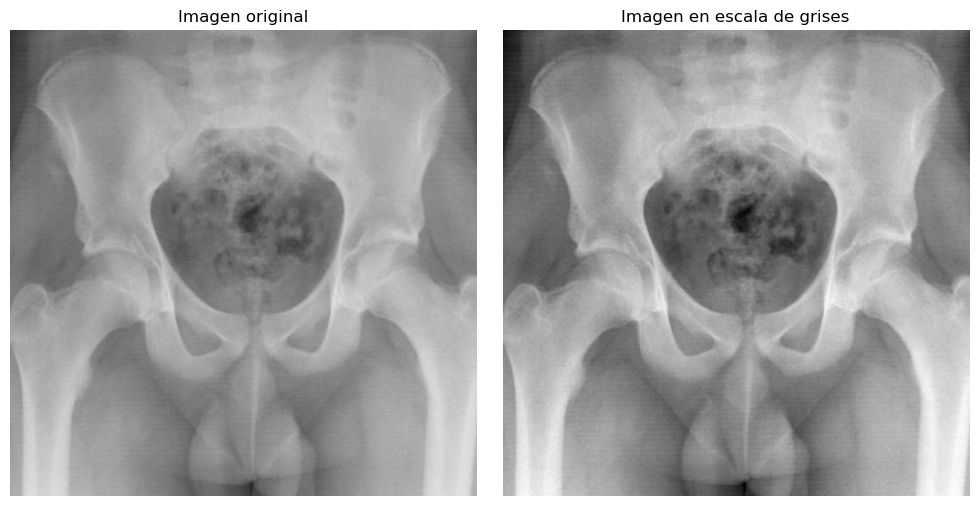

In [107]:
#Mostrar una imagen original y su versión en escala de grises
ruta_ejemplo_relativa = df.iloc[0]["ruta"]
ruta_ejemplo = PROJECT_ROOT / ruta_ejemplo_relativa

img_original = Image.open(ruta_ejemplo)
img_gray = img_original.convert("L")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")

plt.tight_layout()
plt.show()

**Aplicamos filtros a una imagen**



In [101]:
from pathlib import Path

dataset_path = extract_path

exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_paths = [
    p for p in dataset_path.rglob("*")
    if p.suffix.lower() in exts
]

print("Total de imágenes encontradas:", len(image_paths))

Total de imágenes encontradas: 1129


In [ ]:
ruta_img = random.choice(image_paths)

img = Image.open(ruta_img).convert("L")
img_arr = np.array(img).astype(np.uint8)

print("Imagen usada:")
print(ruta_img.relative_to(PROJECT_ROOT))

print("Tamaño:", img_arr.shape)
print("Intensidad mínima:", img_arr.min())
print("Intensidad máxima:", img_arr.max())
print("Intensidad media:", img_arr.mean().round(2))

Imagen usada:
data/raw/dataset_fracturas/Bone Break Classification/Bone Break Classification/Fracture Dislocation/Train/images21_jpg.rf.4ea90dfd023828752d3c3094d4cdcfd9.jpg
Tamaño: (493, 447)
Intensidad mínima: 0
Intensidad máxima: 220
Intensidad media: 108.13


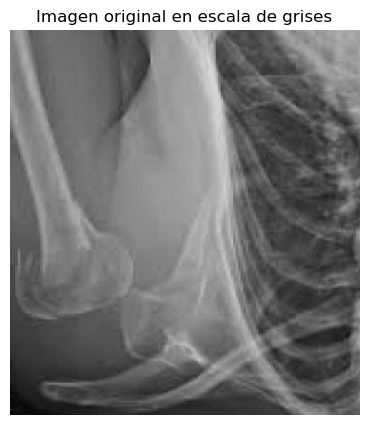

In [106]:
#Mostrar la imagen original
plt.figure(figsize=(5, 5))
plt.imshow(img_arr, cmap="gray", vmin=0, vmax=255)
plt.title("Imagen original en escala de grises")
plt.axis("off")
plt.show()

In [108]:
#Crear las funciones de filtros
def transf_lineal(img, a=1.0, b=0):
    img_float = img.astype(float)
    salida = a * img_float + b
    salida = np.clip(salida, 0, 255)
    return np.rint(salida).astype(np.uint8)


def transf_gamma(img, gamma=1.0, c=1.0):

    img_norm = img.astype(float) / 255.0
    salida = c * (img_norm ** gamma)
    salida = salida * 255
    salida = np.clip(salida, 0, 255)
    return np.rint(salida).astype(np.uint8)


def filtro_media(img, k=3):
    kernel = np.ones((k, k)) / (k * k)
    salida = ndi.convolve(img.astype(float), kernel, mode="reflect")
    return np.clip(salida, 0, 255).astype(np.uint8)


def filtro_mediana(img, k=3):
    salida = ndi.median_filter(img, size=k, mode="reflect")
    return salida.astype(np.uint8)


def unsharp(img, sigma=2, k=1.0):
    img_float = img.astype(float)

    img_blur = ndi.gaussian_filter(img_float, sigma=sigma)
    detalle = img_float - img_blur

    salida = img_float + k * detalle
    salida = np.clip(salida, 0, 255)

    return salida.astype(np.uint8)


def agregar_ruido_gaussiano(img, sigma=18):
    ruido = np.random.normal(0, sigma, img.shape)
    salida = img.astype(float) + ruido
    salida = np.clip(salida, 0, 255)

    return salida.astype(np.uint8)


def agregar_sal_pimienta(img, prob=0.035):
    salida = img.copy()
    rnd = np.random.rand(*img.shape)

    salida[rnd < prob / 2] = 0
    salida[rnd > 1 - prob / 2] = 255

    return salida

In [109]:
#Aplicar degradaciones y filtros
np.random.seed(99)

#Imagen sobreexpuesta artificialmente
sobreexpuesta = transf_lineal(
    img_arr,
    a=1.10,
    b=25
)

#Corrección gamma sobre la imagen sobreexpuesta
gamma_corrige = transf_gamma(
    sobreexpuesta,
    gamma=1.8
)

#Contraste lineal
contraste_lineal = transf_lineal(
    img_arr,
    a=1.35,
    b=-25
)

#Unsharp masking para resaltar bordes
afilado = unsharp(
    img_arr,
    sigma=1.2,
    k=1.0
)

In [110]:
from skimage import exposure

# Paso 1: suavizar ruido impulsivo
temp = filtro_mediana(
    img_arr,
    k=3
)

# Paso 2: mejorar contraste local con CLAHE
clahe = exposure.equalize_adapthist(
    temp / 255.0,
    clip_limit=0.02
)

clahe = np.clip(clahe * 255, 0, 255).astype(np.uint8)

# Paso 3: resaltar bordes
pipeline = unsharp(
    clahe,
    sigma=1.0,
    k=0.7
)

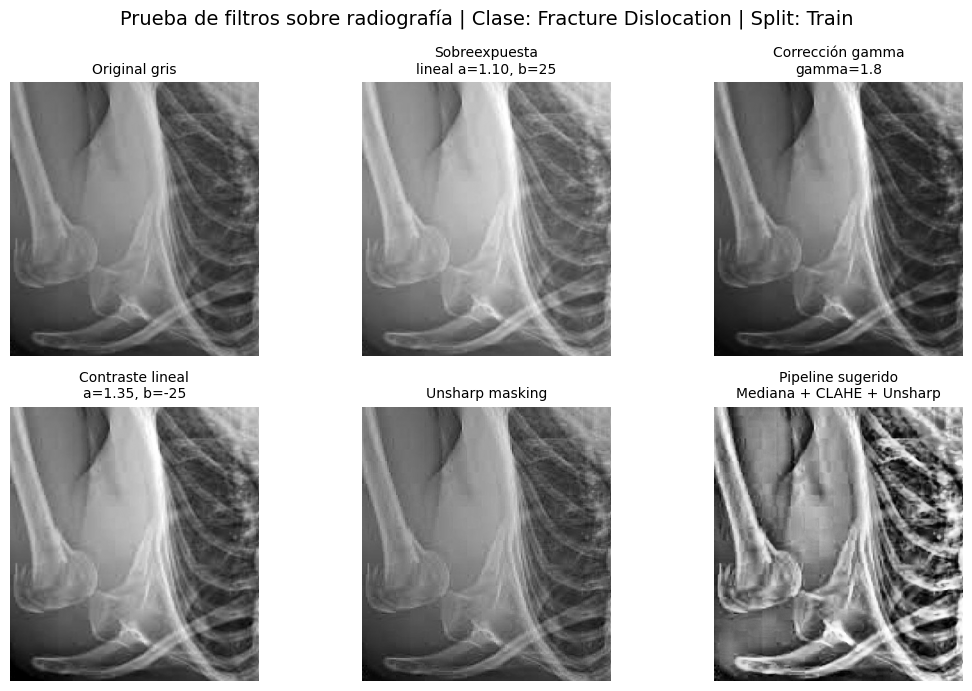

In [111]:
#Mostramos resultados
imagenes = [
    img_arr,
    sobreexpuesta,
    gamma_corrige,
    contraste_lineal,
    afilado,
    pipeline
]

titulos = [
    "Original gris",
    "Sobreexpuesta\nlineal a=1.10, b=25",
    "Corrección gamma\ngamma=1.8",
    "Contraste lineal\na=1.35, b=-25",
    "Unsharp masking",
    "Pipeline sugerido\nMediana + CLAHE + Unsharp"
]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.flatten()

for ax, imagen, titulo in zip(axes, imagenes, titulos):
    ax.imshow(imagen, cmap="gray", vmin=0, vmax=255)
    ax.set_title(titulo, fontsize=10)
    ax.axis("off")

categoria = ruta_img.parent.parent.name
split = ruta_img.parent.name

plt.suptitle(
    f"Prueba de filtros sobre radiografía | Clase: {categoria} | Split: {split}",
    fontsize=14
)

plt.tight_layout()
plt.show()